# Imports

In [22]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch as pt

from torch.utils.data import random_split, DataLoader
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms

import sys

In [23]:
sys.path.append(r"D:\Materials\AI\Projects\Lib\torchwires\src")

from torchwires import Repo, Visualizer, Runner, PassState

# Dataset & Loaders

In [24]:
class DictDataset(Dataset):
    def __init__(self, dataset):
        self.dataset = dataset

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        x, y = self.dataset[idx]

        return {
            "x": x,
            "y": y,
        }

In [25]:
transform = transforms.ToTensor()

full_train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform,
)

train_dataset, val_dataset, test_dataset, _ = random_split(
    full_train_dataset,
    [1000, 300, 300, len(full_train_dataset) - 1600],
)

train_dataset = DictDataset(train_dataset)
val_dataset = DictDataset(val_dataset)
test_dataset = DictDataset(test_dataset)

In [26]:
train_loader = DataLoader(train_dataset, batch_size=50, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=50, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=50, shuffle=False)

# Repo Layout

## Definition

In [27]:
repo = Repo(
    repo_name='repo_1',
)

History cache not found: path=repo_1\exp_1\history.json


## Model

In [28]:
class ClassifierModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.flatten = nn.Flatten()

        self.fc1 = nn.Linear(1 * 28 * 28, 40)
        self.fc2 = nn.Linear(40, 10)
        

    def forward(self, x):
      
        u = self.flatten(x)
        u1 = self.fc1(u)
        u2 = self.fc2(u1)

        return u2

In [29]:
cls_model =  ClassifierModel()

repo.register(
    name='classifier-m',
    value=cls_model
)

Model classifier-m: has been registered
Model classifier-m weights not found: path=repo_1\exp_1\last\classifier-m.weights.pth


## Optimizer

In [30]:
repo.register(
    name='opt-cls',
    value= torch.optim.Adam(cls_model.parameters(), lr=0.01)
)

Optimizer opt-cls: has been registered
Optimizer opt-cls cache not found: path=repo_1\exp_1\last\opt-cls.optimizer.pth


# State

In [31]:
class AppState(PassState):
    x = None
    y = None
    y_hat = None
    ce_loss = None
    accuracy = None
    ce_loss_std = None

## Nodes

In [32]:
def model_pass_node(state: AppState):    
    y_hat = cls_model(state.x)
    
    return {
        'y_hat': y_hat
    }
    

repo.wire(
    name='model-pass',
    body=model_pass_node,
)

Node model-pass: has been registered


In [33]:
def ce_node(state: AppState):
    ce_loss = F.cross_entropy(state.y_hat, state.y)
    
    return {
        'ce_loss': ce_loss
    }
    

repo.wire(
    name='ce_node',
    body=ce_node,
    tracked_features=['ce_loss']
)

Node ce_node: has been registered
Observer tracks: feature=ce_loss


In [34]:
def ce_node_std(state: AppState):
    
    ce_loss_std = torch.std(state.ce_loss, correction=0)
    
    return {
        'ce_loss_std': ce_loss_std
    }
    

repo.wire(
    name='ce_loss_std_node',
    body=ce_node_std,
    tracked_features=['ce_loss_std']
)

Node ce_loss_std_node: has been registered
Observer tracks: feature=ce_loss_std


In [35]:
def acc_node(state: AppState):
    accuracy = state.y_hat.argmax(dim=1).eq(state.y).float().mean()
    
    return {
        'accuracy': accuracy
    }
    

repo.wire(
    name='acc_node',
    body=acc_node,
    tracked_features=['accuracy']
)

Node acc_node: has been registered
Observer tracks: feature=accuracy


# Cache Load

In [36]:
repo.load()

Model classifier-m weights not found: path=repo_1\exp_1\last\classifier-m.weights.pth
Optimizer opt-cls cache not found: path=repo_1\exp_1\last\opt-cls.optimizer.pth
History cache not found: path=repo_1\exp_1\history.json


# Training

In [37]:
runner = Runner(
    repo=repo
)

Runner has been initialized: last complete epoch=None


## cb

In [38]:
# runner.enable_autosave(
#     interval=2,
# )

In [39]:
runner.enable_checkpointing(
    split='val',
    monitor='ce_loss',
    aggregate_mode='mean',
    mode='min'
)

In [40]:
# runner.enable_early_stopping(
#     split= 'val',
#     monitor='accuracy',
#     patience=3,
#     aggregate_mode='mean',
#     mode='max'
# )

## train

In [41]:
runner.train(
    epochs=30,
    backprob_losses=['ce_loss'],
    device='cpu',
    train_loader=train_loader,
    val_loader=val_loader
)

Start training: from epoch=0 to epoch=30

epoch:0 | batch:5 | split:train | device:cpu | ce_loss:1.035017728805542 | ce_loss_std:0.0 | accuracy:0.7200000286102295  

epoch:0 | batch:19 | split:train | device:cpu | ce_loss:0.7356480956077576 | ce_loss_std:0.0 | accuracy:0.7400000095367432 
epoch:0 | batch:5 | split:val | device:cpu | ce_loss:0.5347816348075867 | ce_loss_std:0.0 | accuracy:0.8199999928474426    
Checkpoint: val-ce_loss improved from inf to 0.8027604222297668 | checkpoint name: checkpoint val-ce_loss-min
Model classifier-m weights saved: path=repo_1\exp_1\checkpoint val-ce_loss-min\classifier-m.weights.pth
Optimizer opt-cls weights saved: path=repo_1\exp_1\checkpoint val-ce_loss-min\opt-cls.optimizer.pth
History saved: json=repo_1\exp_1\history.json

epoch:1 | batch:19 | split:train | device:cpu | ce_loss:0.6427000164985657 | ce_loss_std:0.0 | accuracy:0.8600000143051147 
epoch:1 | batch:5 | split:val | device:cpu | ce_loss:0.5196995735168457 | ce_loss_std:0.0 | accuracy:0.8999999761581421    
Checkpoint: val-ce_loss improved from 0.8027604222297668 to 0.7624542117118835 | checkpoint name: checkpoint val-ce_loss-min
Model classifier-m

# Save

In [42]:
repo.save()

Model classifier-m weights saved: path=repo_1\exp_1\last\classifier-m.weights.pth
Optimizer opt-cls weights saved: path=repo_1\exp_1\last\opt-cls.optimizer.pth
History saved: json=repo_1\exp_1\history.json


# Visuals

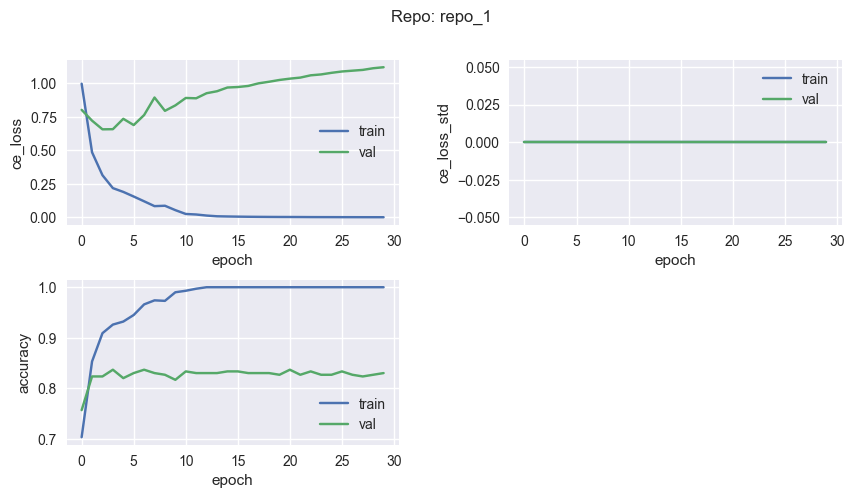

In [43]:
Visualizer.visualize_repo(
    repo=repo,
    n_cols=2
)

In [44]:
Visualizer.display_df(
    repo=repo
)

ce_loss  ce_loss_std  accuracy
epoch split                                 
0     train  0.997864          0.0  0.703000
      val    0.802760          0.0  0.756667
1     train  0.486307          0.0  0.853000
      val    0.722148          0.0  0.823333
2     train  0.315211          0.0  0.909000
      val    0.657523          0.0  0.823333
3     train  0.218889          0.0  0.926000
      val    0.658536          0.0  0.836667
4     train  0.190654          0.0  0.932000
      val    0.736031          0.0  0.820000
5     train  0.156159          0.0  0.945000
      val    0.689358          0.0  0.830000
6     train  0.120528          0.0  0.966000
      val    0.763999          0.0  0.836667
7     train  0.084454          0.0  0.974000
      val    0.894841          0.0  0.830000
8     train  0.087352          0.0  0.973000
      val    0.795499          0.0  0.826667
9     train  0.054625          0.0  0.990000
      val    0.836058          0.0  0.816667
10    train  0.026022          0.0  0.993000
      val    0.891478          0.0  0.833333
11    train  0.022082          0.0  0.997000
      val    0.889067          0.0  0.830000
12    train  0.014160          0.0  1.000000
      val    0.926860          0.0  0.830000
13    train  0.008768          0.0  1.000000
      val    0.941632          0.0  0.830000
14    train  0.007265          0.0  1.000000
      val    0.969466          0.0  0.833333
15    train  0.006101          0.0  1.000000
      val    0.973137          0.0  0.833333
16    train  0.005172          0.0  1.000000
      val    0.981178          0.0  0.830000
17    train  0.004491          0.0  1.000000
      val    1.000770          0.0  0.830000
18    train  0.003963          0.0  1.000000
      val    1.012529          0.0  0.830000
19    train  0.003589          0.0  1.000000
      val    1.025777          0.0  0.826667
20    train  0.003430          0.0  1.000000
      val    1.035621          0.0  0.836667
21    train  0.003161          0.0  1.000000
      val    1.043451          0.0  0.826667
22    train  0.002700          0.0  1.000000
      val    1.060501          0.0  0.833333
23    train  0.002518          0.0  1.000000
      val    1.067116          0.0  0.826667
24    train  0.002390          0.0  1.000000
      val    1.079115          0.0  0.826667
25    train  0.002182          0.0  1.000000
      val    1.089054          0.0  0.833333
26    train  0.002101          0.0  1.000000
      val    1.095004          0.0  0.826667
27    train  0.001922          0.0  1.000000
      val    1.100876          0.0  0.823333
28    train  0.001827          0.0  1.000000
      val    1.113248          0.0  0.826667
29    train  0.001759          0.0  1.000000
      val    1.120870          0.0  0.830000

# Predict

In [45]:
x, y = test_dataset[0]['x'], test_dataset[0]['y']

x = pt.stack([x])
y = pt.tensor([y])

s = runner.inference(
    device='cpu',
    inputs={
        'x': x,
        'y': y
    }
)

print(s.keys())

dict_keys(['epoch', 'batch', 'split', 'device', 'x', 'y', 'y_hat', 'ce_loss', 'ce_loss_std', 'accuracy'])
